In [5]:
!pip install ninja


[notice] A new release of pip is available: 23.3.1 -> 24.3.1
[notice] To update, run: python -m pip install --upgrade pip


In [6]:
!git clone https://github.com/PeikeLi/Self-Correction-Human-Parsing
%cd Self-Correction-Human-Parsing
!mkdir checkpoints
!mkdir inputs
!mkdir outputs

Cloning into 'Self-Correction-Human-Parsing'...


remote: Enumerating objects: 722, done.
remote: Counting objects: 100% (176/176), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 722 (delta 74), reused 64 (delta 64), pack-reused 546 (from 1)
Receiving objects: 100% (722/722), 3.88 MiB | 3.76 MiB/s, done.
Resolving deltas: 100% (150/150), done.
Updating files: 100% (545/545), done.
/workspace/Self-Correction-Human-Parsing


/usr/local/lib/python3.10/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [7]:
dataset = 'lip'

In [9]:
!pip install gdown

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 9.5 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.3.1 -> 24.3.1
[notice] To update, run: python -m pip install --upgrade pip


In [10]:
import gdown

if dataset == 'lip':
    url = 'https://drive.google.com/uc?id=1k4dllHpu0bdx38J7H28rVVLpU-kOHmnH'
elif dataset == 'atr':
    url = 'https://drive.google.com/uc?id=1ruJg4lqR_jgQPj-9K0PP-L2vJERYOxLP'
elif dataset == 'pascal':
    url = 'https://drive.google.com/uc?id=1E5YwNKW2VOEayK9mWCS3Kpsxf-3z04ZE'

output = 'checkpoints/final.pth'
gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1k4dllHpu0bdx38J7H28rVVLpU-kOHmnH
From (redirected): https://drive.google.com/uc?id=1k4dllHpu0bdx38J7H28rVVLpU-kOHmnH&confirm=t&uuid=7ff3bfc4-aa65-41ce-a7a6-1f630abf3a71
To: /workspace/Self-Correction-Human-Parsing/checkpoints/final.pth
100%|██████████| 267M/267M [00:07<00:00, 33.5MB/s] 


'checkpoints/final.pth'

In [12]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 98.2 MB/s eta 0:00:00:00:0100:01

[notice] A new release of pip is available: 23.3.1 -> 24.3.1
[notice] To update, run: python -m pip install --upgrade pip


In [16]:
#semantically parsing source head and body
!python3 simple_extractor.py --dataset 'lip' --model-restore 'checkpoints/final.pth' --input-dir 'inputs' --output-dir 'outputs'

Evaluating total class number 20 with ['Background', 'Hat', 'Hair', 'Glove', 'Sunglasses', 'Upper-clothes', 'Dress', 'Coat', 'Socks', 'Pants', 'Jumpsuits', 'Scarf', 'Skirt', 'Face', 'Left-arm', 'Right-arm', 'Left-leg', 'Right-leg', 'Left-shoe', 'Right-shoe']
100%|█████████████████████████████████████████████| 2/2 [00:03<00:00,  1.93s/it]


In [20]:
!pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.1/165.1 kB 4.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 162.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 103.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 236.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 189.0 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.3.1 -> 24.3.1
[notice] To update, run: python -m pip install --upgrade pip


In [ ]:
"""
1. parse input images semantically
2. find the head in both images
3. align the head from the source head proportional to the source body head
4. get the body of the source body
5. blend the body of the source body together with the resized source head
6. insert the real head into the real body
"""

In [32]:
import numpy as np

def extract_labels(parsing_result, labels_to_extract):
    """
    Extracts specific labels from a semantic parsing result.

    Args:
        parsing_result: The semantic parsing output (image or NumPy array).
        labels_to_extract: A list or set of LIP labels to extract.

    Returns:
        A binary mask where pixels with the specified labels are 1, others are 0.
    """

    # Convert parsing result to NumPy array if needed
    if not isinstance(parsing_result, np.ndarray):
        parsing_result = np.array(parsing_result)

    # Create the mask
    mask = np.isin(parsing_result, list(labels_to_extract))

    return mask.astype(np.uint8) * 255  # Convert to uint8 with 2

In [33]:
from IPython.display import display
from PIL import Image

def display_mask(mask):
  """Displays a mask as an image in Colab.

  Args:
    mask: The mask to display (NumPy array).
  """
  display(Image.fromarray(mask))

In [34]:
# Assuming the parsing result image is in the 'outputs' directory:
jensen_parsing_result = Image.open('outputs/jensen.png')
elon_parsing_result = Image.open('outputs/elon.png')

In [45]:
# Extract head masks
jensen_head_mask = extract_labels(jensen_parsing_result, [1, 2, 4, 13])  # Hat, Hair, Sunglasses, Face
elon_head_mask = extract_labels(elon_parsing_result, [1, 2, 4, 13])  # Hat, Hair, Sunglasses, Face

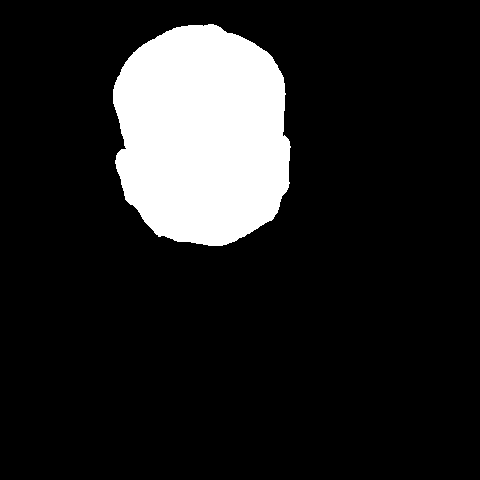

In [46]:
display_mask(jensen_head_mask)

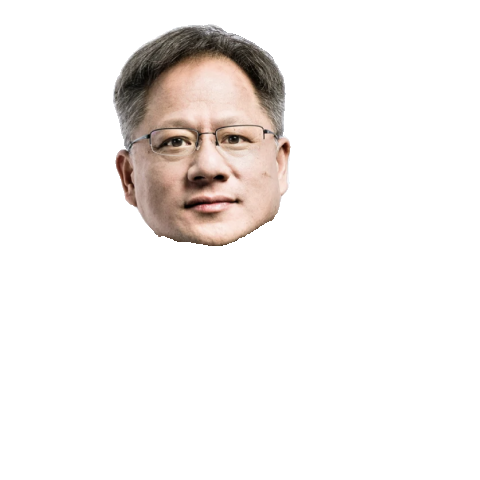

In [51]:
# Load the original RGB image
jensen_rgb = Image.open('inputs/jensen.png')

# Convert images to numpy arrays for manipulation
jensen_rgb_array = np.array(jensen_rgb)
jensen_mask_array = jensen_head_mask

# Apply the mask to the RGB image
# Expand mask dimensions to match RGB (add channel dimension)
jensen_mask_3d = jensen_mask_array[:, :, np.newaxis] / 255.0  # Normalize mask to 0-1
jensen_head_rgb = (jensen_rgb_array * jensen_mask_3d).astype(np.uint8)

# Display the masked RGB head
display(Image.fromarray(jensen_head_rgb))

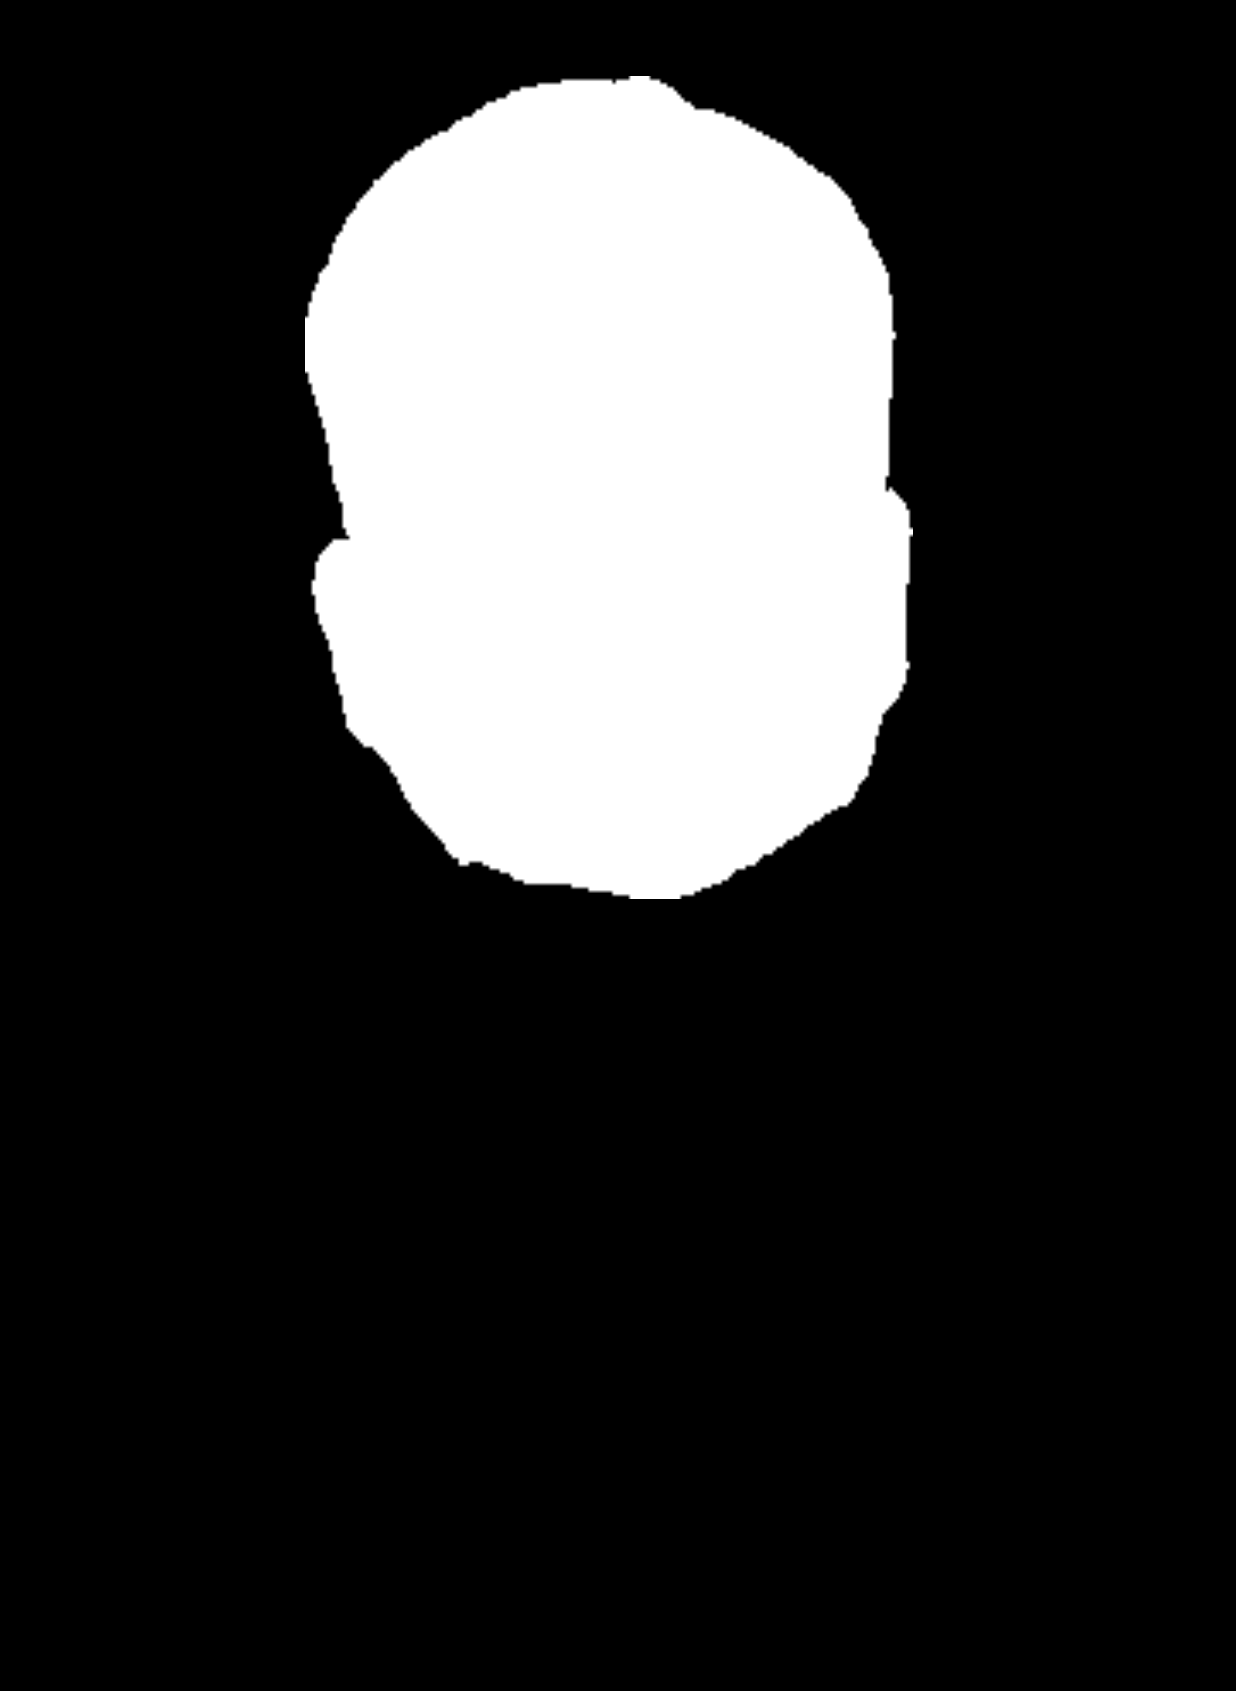

In [37]:
import cv2

def align_head(source_head_mask, target_head_mask):
    """
    Aligns and resizes the source head to match the target head position and size.
    
    Args:
        source_head_mask: Binary mask of the source head
        target_head_mask: Binary mask of the target head (where head should be placed)
    
    Returns:
        Transformed source head mask aligned to target position
    """
    # Find contours of both heads
    source_contours, _ = cv2.findContours(source_head_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    target_contours, _ = cv2.findContours(target_head_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not source_contours or not target_contours:
        raise ValueError("No head contours found in one or both masks")
    
    # Get bounding boxes
    source_rect = cv2.boundingRect(max(source_contours, key=cv2.contourArea))
    target_rect = cv2.boundingRect(max(target_contours, key=cv2.contourArea))
    
    # Extract source head region
    x, y, w, h = source_rect
    source_head = source_head_mask[y:y+h, x:x+w]
    
    # Calculate target dimensions
    target_x, target_y, target_w, target_h = target_rect
    
    # Resize source head to match target dimensions
    aligned_head = cv2.resize(source_head, (target_w, target_h))
    
    # Create output mask of same size as target
    result = np.zeros_like(target_head_mask)
    
    # Place resized head in the correct position
    result[target_y:target_y+target_h, target_x:target_x+target_w] = aligned_head
    
    return result

# Use the function
aligned_head_mask = align_head(jensen_head_mask,elon_head_mask)
display_mask(aligned_head_mask)

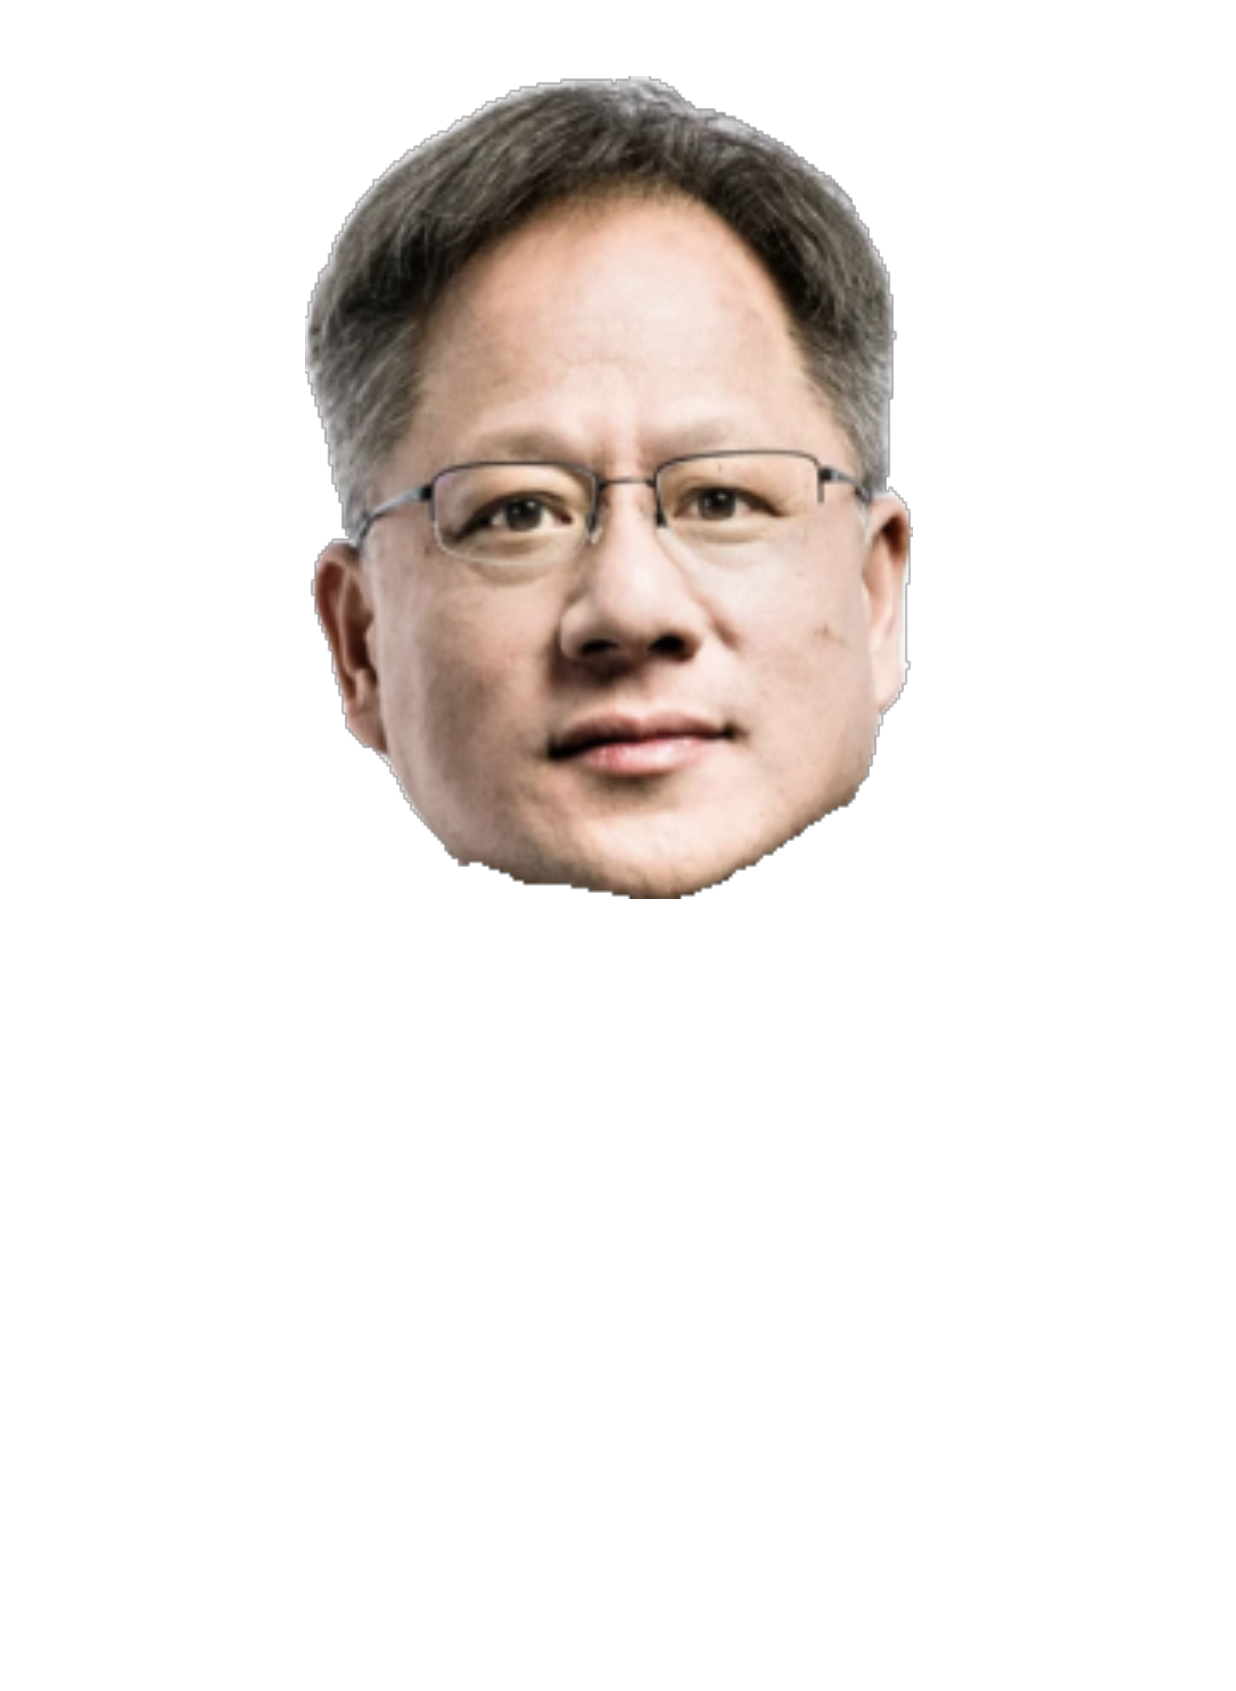

In [53]:
def align_rgb_head(source_rgb, source_mask, target_mask):
    """
    Aligns and resizes the source RGB head using the same transformations as the mask.
    """
    # Find contours of both heads
    source_contours, _ = cv2.findContours(source_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    target_contours, _ = cv2.findContours(target_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Get bounding boxes
    source_rect = cv2.boundingRect(max(source_contours, key=cv2.contourArea))
    target_rect = cv2.boundingRect(max(target_contours, key=cv2.contourArea))
    
    # Extract source head region from RGB image
    x, y, w, h = source_rect
    source_head_rgb = source_rgb[y:y+h, x:x+w]
    
    # Calculate target dimensions
    target_x, target_y, target_w, target_h = target_rect
    
    # Resize source head to match target dimensions
    aligned_head_rgb = cv2.resize(source_head_rgb, (target_w, target_h))
    
    # Create output image of same size as target mask
    result = np.zeros((target_mask.shape[0], target_mask.shape[1], source_rgb.shape[2]), dtype=np.uint8)
    
    # Place resized head in the correct position
    result[target_y:target_y+target_h, target_x:target_x+target_w] = aligned_head_rgb
    
    return result

# Align the RGB head
aligned_rgb_head = align_rgb_head(jensen_head_rgb, jensen_head_mask, elon_head_mask)
display(Image.fromarray(aligned_rgb_head))

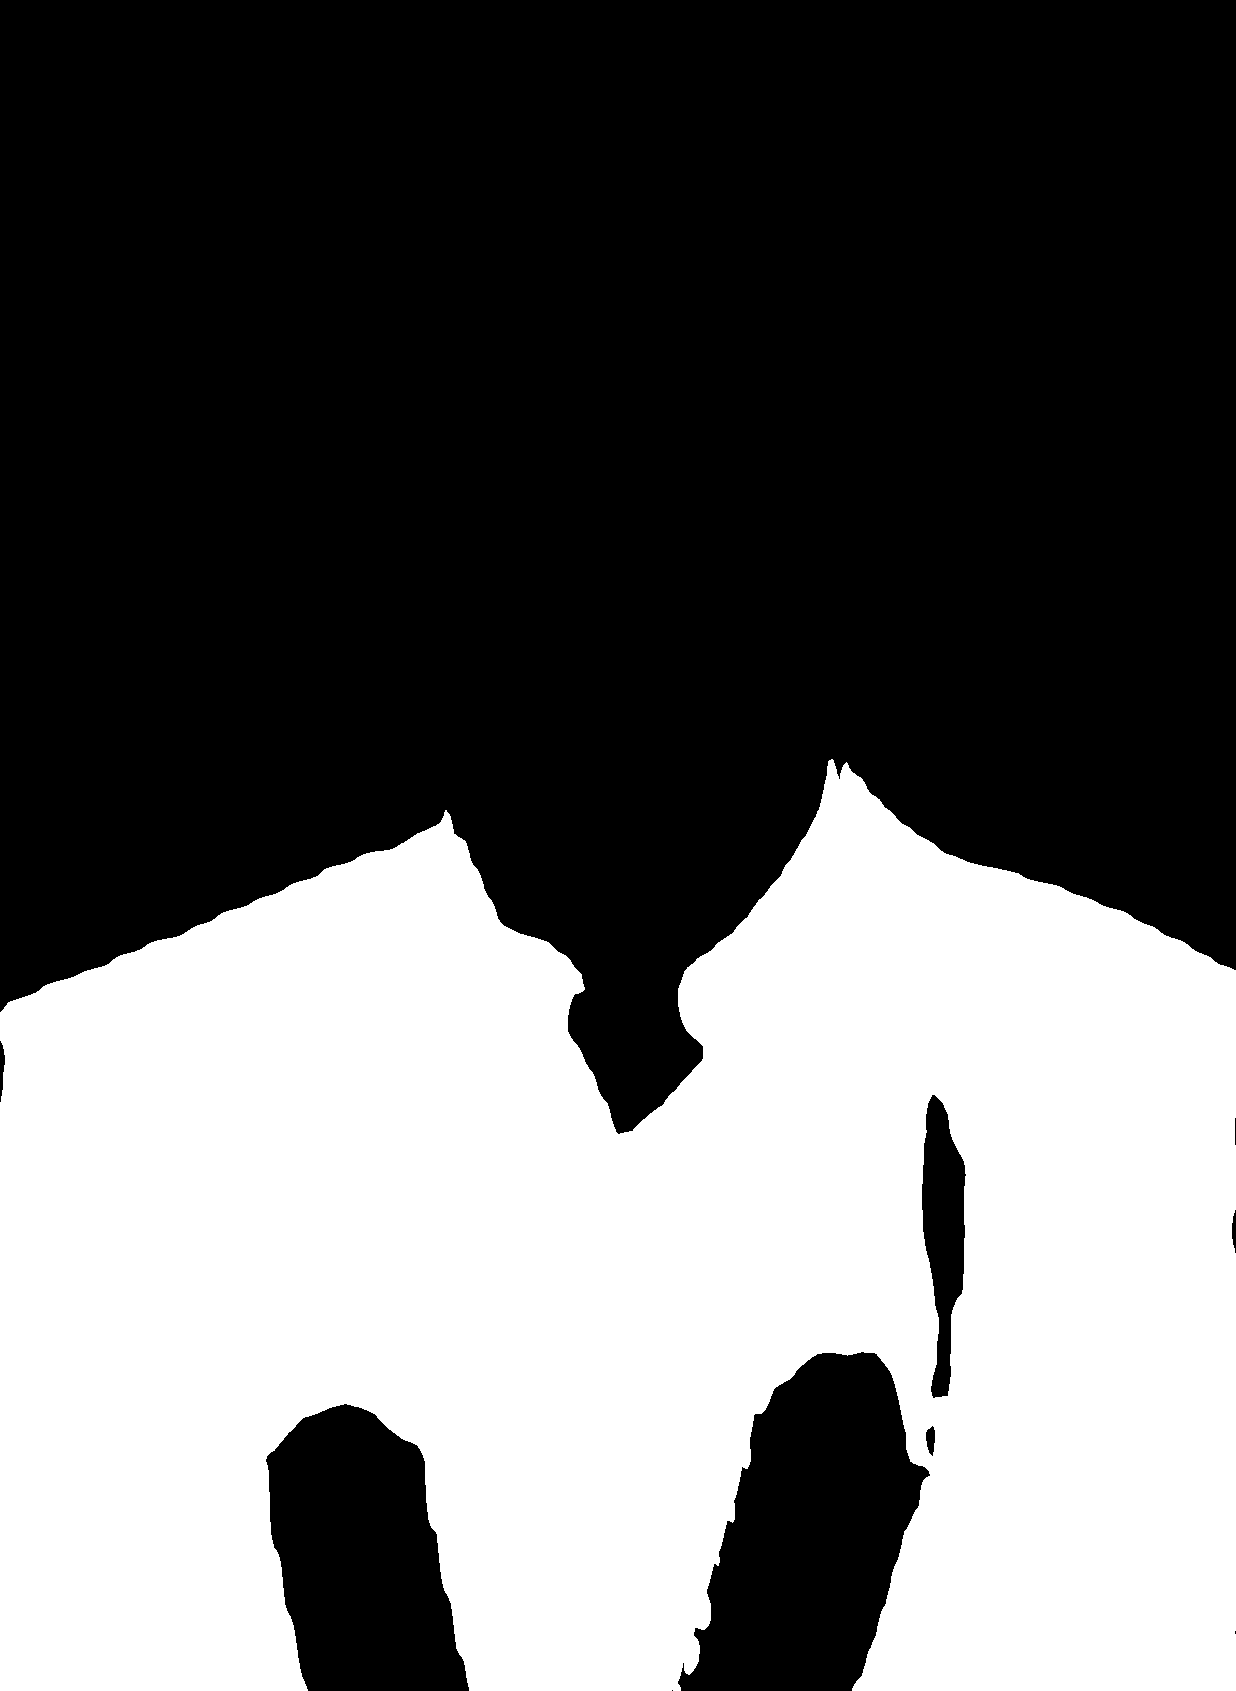

In [38]:
# Extract body mask (excluding head parts)
body_labels = [5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19]  # All body parts except head
# 5: Upper-clothes
# 6: Dress
# 7: Coat
# 8: Socks
# 9: Pants
# 10: Jumpsuits
# 11: Scarf
# 12: Skirt
# 14: Left-arm
# 15: Right-arm
# 16: Left-leg
# 17: Right-leg
# 18: Left-shoe
# 19: Right-shoe

# Get body mask from the target person
target_body_mask = extract_labels(elon_parsing_result, body_labels)

# Visualize the result
display_mask(target_body_mask)

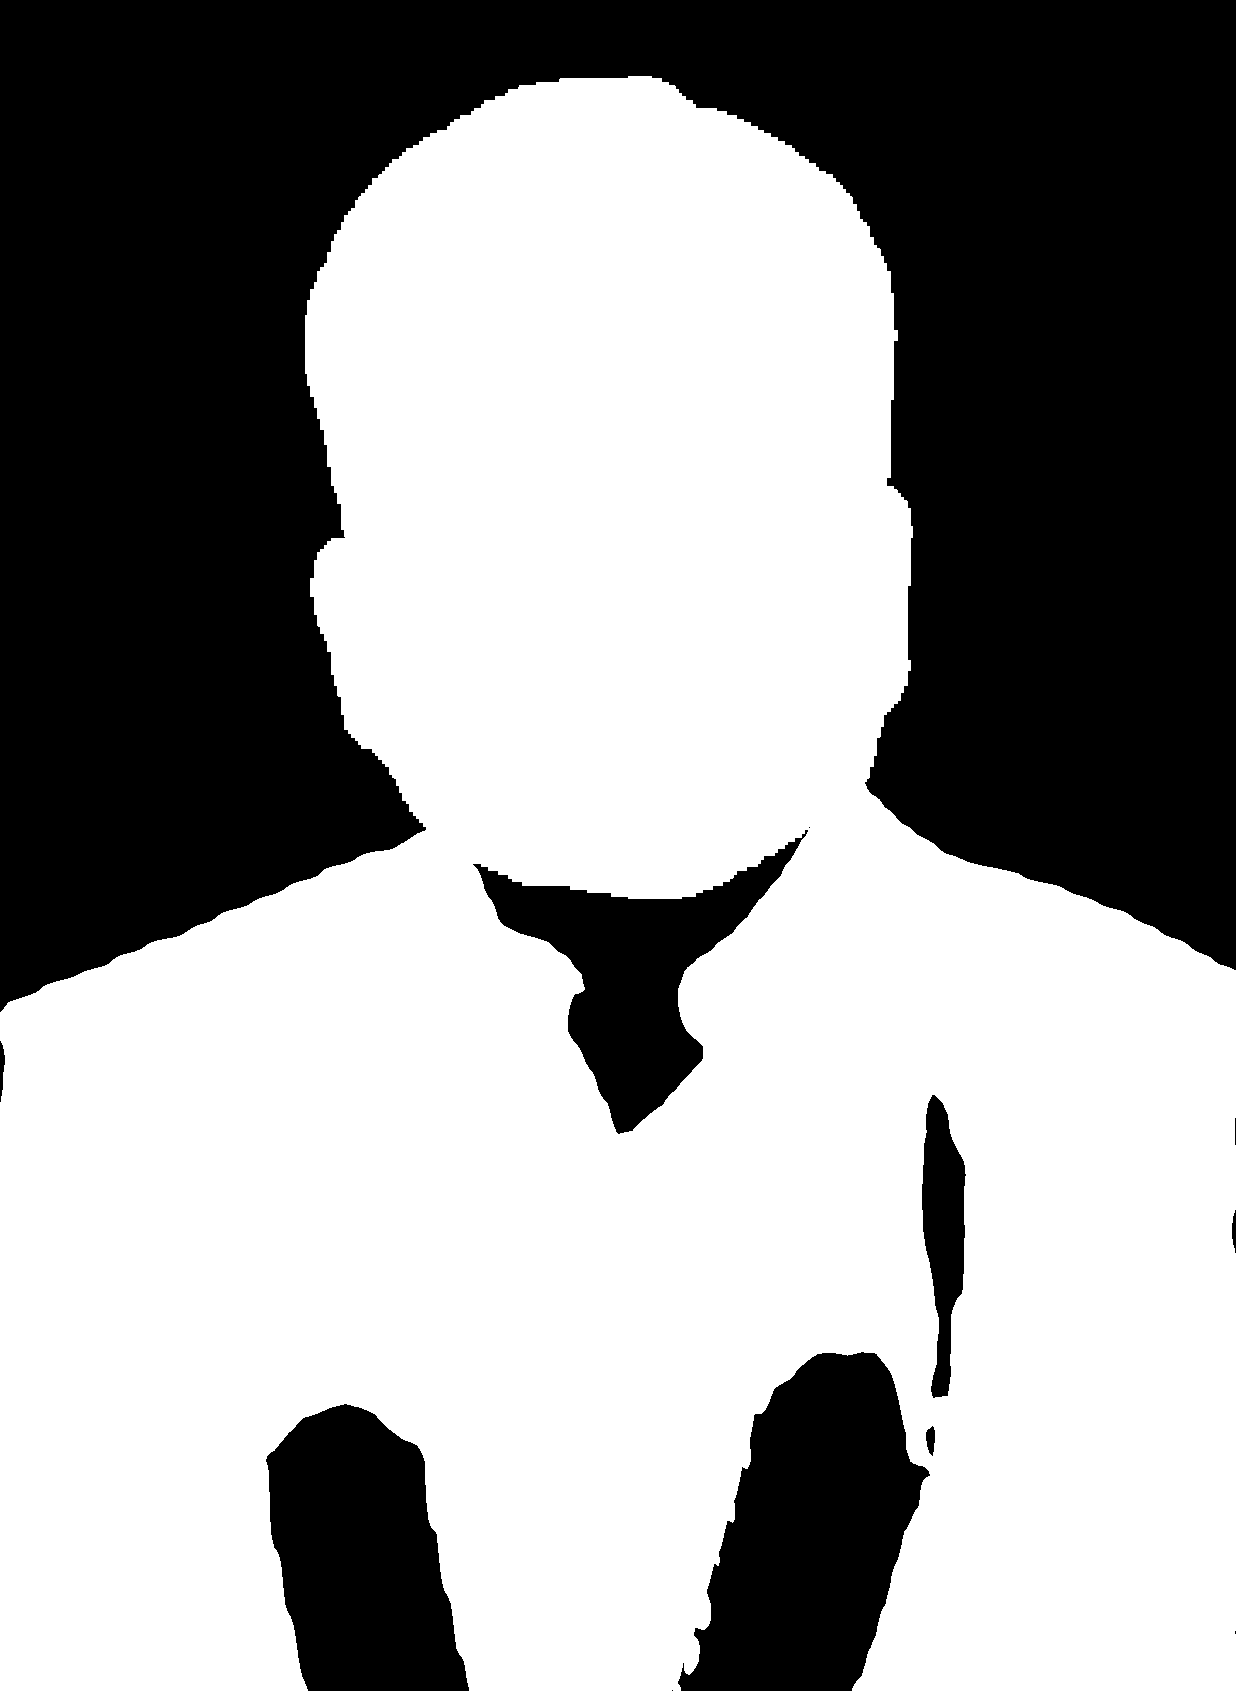

In [39]:
def blend_binary_masks(aligned_head_mask, body_mask):
    """
    Combines the binary masks of the aligned head and body.
    
    Args:
        aligned_head_mask: Binary mask of the aligned source head
        body_mask: Binary mask of the target body
    
    Returns:
        Combined binary mask
    """
    # Ensure masks are binary (0 or 255)
    head_mask = (aligned_head_mask > 0).astype(np.uint8) * 255
    body_mask = (body_mask > 0).astype(np.uint8) * 255
    
    # Combine masks (taking maximum value at each pixel)
    combined_mask = np.maximum(head_mask, body_mask)
    
    return combined_mask

# Blend the masks
combined_mask = blend_binary_masks(aligned_head_mask, target_body_mask)

# Display result
display_mask(combined_mask)

In [40]:
import matplotlib.pyplot as plt

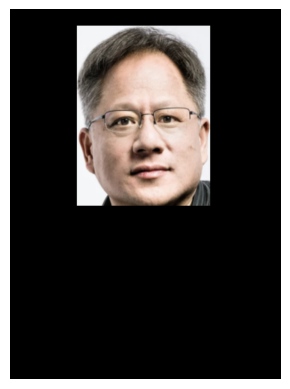

In [44]:
def align_rgb_head(source_rgb, source_head_mask, target_head_mask):
    """
    Aligns and resizes the RGB source head using the mask transformations.
    
    Args:
        source_rgb: Original RGB image containing the source head
        source_head_mask: Binary mask of the source head
        target_head_mask: Binary mask of the target head
    
    Returns:
        Transformed RGB head aligned to target position
    """
    # Find contours of both heads
    source_contours, _ = cv2.findContours(source_head_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    target_contours, _ = cv2.findContours(target_head_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not source_contours or not target_contours:
        raise ValueError("No head contours found in one or both masks")
    
    # Get bounding boxes
    source_rect = cv2.boundingRect(max(source_contours, key=cv2.contourArea))
    target_rect = cv2.boundingRect(max(target_contours, key=cv2.contourArea))
    
    # Extract source head region from RGB image
    x, y, w, h = source_rect
    source_head_rgb = source_rgb[y:y+h, x:x+w]
    
    # Calculate target dimensions
    target_x, target_y, target_w, target_h = target_rect
    
    # Resize source head to match target dimensions
    aligned_head_rgb = cv2.resize(source_head_rgb, (target_w, target_h))
    
    # Create output image of same size as target
    result = np.zeros((*target_head_mask.shape, 3), dtype=np.uint8)
    
    # Place resized head in the correct position
    result[target_y:target_y+target_h, target_x:target_x+target_w] = aligned_head_rgb
    
    return result

# Load the original RGB image
jensen_rgb = cv2.imread('inputs/jensen.png')
jensen_rgb = cv2.cvtColor(jensen_rgb, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

# Align the RGB head
aligned_rgb_head = align_rgb_head(jensen_rgb, jensen_head_mask, elon_head_mask)

# Display result
plt.imshow(aligned_rgb_head)
plt.axis('off')
plt.show()